# Experiment 3. 

Mario Chacón Falcón, Jose M. Moyano.

The goal of experiment 3 is to choose the best parameters for the model. In this experiment the best between client_and_server (and its variations) and only_server parameter will be chosen. 

Last experiment performed best with w_m_v + common_weighted,  wmv+own and m_v common_weighted, so comparisons will be performed with all possible combinations of the parameters with these three. 

In [1]:
from flextrees.datasets.tabular_datasets import bank
from flextrees.datasets.tabular_datasets import nursery
from flextrees.datasets.tabular_datasets import adult
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from utils.evaluation import FL_simple_cross_val_score
from sklearn.datasets import load_breast_cancer
import time
import math
from statds.no_parametrics import friedman, bonferroni, nemenyi
import os

In [2]:
train_data, test_data = bank(ret_feature_names=False, categorical=False)
X_data,y_data = train_data.to_numpy()
X_test,y_test = test_data.to_numpy()
X_data_bank = np.concatenate((X_data,X_test)).astype(int) #Some were bools
targets_bank = np.concatenate((y_data,y_test))
train_data, test_data = adult(ret_feature_names=False, categorical=False)
X_data,y_data = train_data.to_numpy()
X_test,y_test = test_data.to_numpy()
X_data_adult = np.concatenate((X_data,X_test))
targets_adult = np.concatenate((y_data,y_test))
train_data, test_data = nursery(ret_feature_names=False, categorical=False)
X_data,y_data = train_data.to_numpy()
X_test,y_test = test_data.to_numpy()
X_data_nursery = np.concatenate((X_data,X_test))
targets_nursery = np.concatenate((y_data,y_test))

In [5]:
breast_cancer = load_breast_cancer()
X_data_bcancer = breast_cancer.data
targets_bcancer = breast_cancer.target

In [6]:
def experiment3search(datasets,data_distribution,distribution_param = None,public_data_prediction='weighted_majority_voting',server_alpha_weight_adj='common_weighted'):

    #Algorithm parameters:
    Nclients = 10
    #server_alpha_weight_adj = 'own' 
    #prediction_weights = 'server_and_clients'
    T = 10
    adapt_client_weight1 = np.ones(Nclients)
    #Tuple containing if server or only server, if balanced to amount of data and if balanced to labels. 
    parameters = [('only_server',None,False),('server_and_clients',adapt_client_weight1,False),('server_and_clients',adapt_client_weight1,True),
                  ('server_and_clients',None,False),('server_and_clients',adapt_client_weight1,True)]
    parametersnames = ['only_server','s_cl_nb_nb','s_cl_nb_b','s_cl_b_nb','s_cl_b_b']
    #Default settings
    seeds =[0,142,242,342,442,542]
    parameterscolumns = ['only_server','only_server_std','s_cl_nb_nb','s_cl_nb_nb_std','s_cl_nb_b','s_cl_nb_b_std','s_cl_b_nb','s_cl_b_nb_std','s_cl_b_b','s_cl_b_b_std']

    #Creates dataframes to store avg results : FL on global data, FL on local data, centralized model scores (f1 and acc)
    dataframeacc_globaldata = pd.DataFrame(np.nan, index= datasets.keys(),
                            columns = parameterscolumns)
    dataframeacc_globaldata = dataframeacc_globaldata.rename_axis('FLGlobal_acc',axis=1)
    dataframef1_globaldata = pd.DataFrame(np.nan, index= datasets.keys(),
                            columns = parameterscolumns)
    dataframef1_globaldata = dataframef1_globaldata.rename_axis('FLGlobal_f1',axis=1)
    dataframeacc_localdata = pd.DataFrame(np.nan, index= datasets.keys(),
                            columns = parameterscolumns)
    dataframeacc_localdata = dataframeacc_localdata.rename_axis('FLlocal_acc',axis=1)
    dataframef1_localdata = pd.DataFrame(np.nan, index= datasets.keys(),
                            columns = parameterscolumns)
    dataframef1_localdata = dataframef1_localdata.rename_axis('FLlocal_f1',axis=1)
    dataframe_centralizedacc = pd.DataFrame(np.nan, index = datasets.keys(),columns = ['mean','std'])
    dataframe_centralizedacc = dataframe_centralizedacc.rename_axis('centralized_acc',axis=1)
    dataframe_centralizedf1 = pd.DataFrame(np.nan, index = datasets.keys(),columns = ['mean','std'])
    dataframe_centralizedf1 = dataframe_centralizedf1.rename_axis('centralized_f1',axis=1)

    acc_results = []
    f1_results = []

    #Training of 6 5-folds for each dataset and then gets stored in its corresponding row. 
    for dataset,data in datasets.items():
        data_to_mergeacc = [[]]*len(parameters)
        data_to_mergef1 = [[]]*len(parameters)
        centralized_acc = []
        centralized_f1 = []
        for seed in seeds: 
            fulldata,fulltargets = data
            X_data,public_data,y_data,public_data_targets = train_test_split(fulldata,fulltargets,
                                                                            train_size=0.75,random_state=seed)
            #Create folds
            skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=seed)
            indices_iterable = skf.split(X_data,y_data)
            
            dataset_splits = [None]*5
            for i,(filter_train,filter_test) in enumerate(indices_iterable):
                dataset_splits[i] = (X_data[filter_train],X_data[filter_test],
                                    y_data[filter_train],y_data[filter_test])
            
            aux_acc_dataframe = pd.DataFrame(np.nan, index = [dataset+str(seed)]*len(dataset_splits),columns = parametersnames)
            aux_f1_dataframe = pd.DataFrame(np.nan, index = [dataset+str(seed)]*len(dataset_splits),columns = parametersnames) 
                
            for i,parameter in enumerate(parameters):
                prediction_weights,adapt_client_weight,balanced = parameter
                FLmodels,centralized_models,accDataFrames,F1DataFrames,acc_centralized_model_scores,f1_centralized_model_scores = FL_simple_cross_val_score(dataset_splits,
                                public_data,Nclients=Nclients,
                                public_data_prediction=public_data_prediction,server_alpha_weight_adj=server_alpha_weight_adj,
                                prediction_weights=prediction_weights,T=T,data_distribution=data_distribution,distribution_param=distribution_param,random_state=seed,
                                adapt_client_weight=adapt_client_weight,balanced_target_client_weight=balanced)
                for j,accDataFrame in enumerate(accDataFrames):
                    aux_acc_dataframe.iloc[j,i] = accDataFrame.loc[:]['FL_acc_global_data'].mean()
                    aux_f1_dataframe.iloc[j,i] = F1DataFrames[j].loc[:]['FL_acc_global_data'].mean()
                
                data_to_mergeacc[i] = data_to_mergeacc[i] + accDataFrames
                data_to_mergef1[i] = data_to_mergef1[i] + F1DataFrames
            
            acc_results.append(aux_acc_dataframe)
            f1_results.append(aux_f1_dataframe)

            #In each parameter the centralized score does not change, hence, we only store the last ones.
            centralized_acc = centralized_acc + acc_centralized_model_scores
            centralized_f1 = centralized_f1 + f1_centralized_model_scores
        #Once we've done all the tests in all the parameters and seeds for the given dataset, we store it in the dataframes and 
        #start with the next one
        for i in range(len(data_to_mergeacc)):
            data_to_mergeacc[i] = pd.concat(data_to_mergeacc[i],axis=0).describe().loc[['mean','std']][['FL_acc_own_data','FL_acc_global_data']]
            data_to_mergef1[i] = pd.concat(data_to_mergef1[i],axis=0).describe().loc[['mean','std']][['FL_acc_own_data','FL_acc_global_data']]
        
        arr_centralized_acc = np.array(centralized_acc)
        arr_centralized_f1 = np.array(centralized_f1)
        dataframeacc = pd.concat(data_to_mergeacc,axis=0)
        dataframef1 = pd.concat(data_to_mergef1,axis=0)
        dataframeacc_globaldata.loc[dataset] = dataframeacc.iloc[:,1].values
        dataframeacc_localdata.loc[dataset] = dataframeacc.iloc[:,0].values
        dataframef1_globaldata.loc[dataset] = dataframef1.iloc[:,1].values
        dataframef1_localdata.loc[dataset] = dataframef1.iloc[:,0].values
        dataframe_centralizedacc.loc[dataset] = (arr_centralized_acc.mean(),arr_centralized_acc.std())
        dataframe_centralizedf1.loc[dataset] = (arr_centralized_f1.mean(),arr_centralized_f1.std())

    statistics_acc = pd.concat(acc_results,axis=0)
    statistics_acc = statistics_acc.rename_axis('FL_global_acc')
    statistics_f1 = pd.concat(f1_results,axis=0)
    statistics_f1 = statistics_f1.rename_axis('FL_global_f1')
    return dataframeacc_globaldata,dataframeacc_localdata,dataframe_centralizedacc,dataframef1_globaldata,dataframef1_localdata,dataframe_centralizedf1,statistics_acc,statistics_f1

In [7]:
datasets = {'bank':(X_data_bank,targets_bank),
            'adult':(X_data_adult,targets_adult),'nursery':(X_data_nursery,targets_nursery),'bcancer':(X_data_bcancer,targets_bcancer)}

# Notation: 

only_server is only server mode

s_cl_nb_nb is server_and_clients mode, where the clients models coeficients are not multiplied by anything.

s_cl_b_nb is server_and_clients mode, where the ith client models coeficients are multiplied by $\frac{d_i}{\sum_i^N d_i}$, where d_i is the amount of data the ith client has. This coeficient makes those clients with less data use less their coeficients , since it is supposed that less data will lead to poorer performance on their own. 

s_cl_nb_b is server_and_clients mode, where the ith client models coeficients are multiplied by $(\frac{y_i-|y_i-y_j|}{y_i})$. Where $y_i,y_j$ are the first and second classes in the training data of client i with the most data respectively. This way, a client with a dataset that mostly has one class label will not contribute much to the personalized prediction of the FL model. 

s_cl_b_b is server_and_clients mode, but with coeficient (mix of the last two): $\frac{d_i}{\sum_i d_i}*(\frac{y_i-|y_i-y_j|}{y_i})$

# IID

In [8]:
time0 = time.time()
iidresultsW_cw = experiment3search(data_distribution='iid',datasets=datasets)
print("\n[INFO] Total Time (in minutes) =", (time.time() - time0) / 60)
for result in iidresultsW_cw:
    print(result)

c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\O


[INFO] Total Time (in minutes) = 23.339220094680787
FLGlobal_acc  only_server  only_server_std  s_cl_nb_nb  s_cl_nb_nb_std  \
bank            88.912647         0.280877   85.037306        0.584302   
adult           84.640322         0.515705   80.261876        0.740686   
nursery         94.344993         0.553027   90.584705        1.273772   
bcancer         90.573187         3.434732   89.000046        4.270918   

FLGlobal_acc  s_cl_nb_b  s_cl_nb_b_std  s_cl_b_nb  s_cl_b_nb_std   s_cl_b_b  \
bank          88.912647       0.280877  88.912647       0.280877  88.912647   
adult         83.893735       0.671205  84.640322       0.515705  83.893735   
nursery       90.631001       1.279743  94.344993       0.553027  90.631001   
bcancer       90.135203       3.798633  91.076334       3.182974  90.135203   

FLGlobal_acc  s_cl_b_b_std  
bank              0.280877  
adult             0.671205  
nursery           1.279743  
bcancer           3.798633  
FLlocal_acc  only_server  only_serv

In [9]:
time0 = time.time()
iidresultsW_own = experiment3search(data_distribution='iid',datasets=datasets,server_alpha_weight_adj='own')
print("\n[INFO] Total Time (in minutes) =", (time.time() - time0) / 60)
for result in iidresultsW_own:
    print(result)
    


c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\O


[INFO] Total Time (in minutes) = 23.424728178977965
FLGlobal_acc  only_server  only_server_std  s_cl_nb_nb  s_cl_nb_nb_std  \
bank            88.912647         0.280877   85.037306        0.584302   
adult           84.640322         0.515705   80.261876        0.740686   
nursery         94.344822         0.553052   90.627572        1.273022   
bcancer         88.148564         5.020896   89.136890        4.099958   

FLGlobal_acc  s_cl_nb_b  s_cl_nb_b_std  s_cl_b_nb  s_cl_b_nb_std   s_cl_b_b  \
bank          88.912647       0.280877  88.912647       0.280877  88.912647   
adult         83.815588       0.909516  84.640322       0.515705  83.815588   
nursery       90.698045       1.278704  94.344993       0.553027  90.698045   
bcancer       89.610898       3.953966  89.313725       4.098037  89.610898   

FLGlobal_acc  s_cl_b_b_std  
bank              0.280877  
adult             0.909516  
nursery           1.278704  
bcancer           3.953966  
FLlocal_acc  only_server  only_serv

In [10]:
time0 = time.time()
iidresults_cw = experiment3search(data_distribution='iid',datasets=datasets,public_data_prediction='majority_voting')
print("\n[INFO] Total Time (in minutes) =", (time.time() - time0) / 60)
for result in iidresults_cw:
    print(result)
    


c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\O


[INFO] Total Time (in minutes) = 17.27821550766627
FLGlobal_acc  only_server  only_server_std  s_cl_nb_nb  s_cl_nb_nb_std  \
bank            88.282510         0.084667   85.037306        0.584302   
adult           75.902266         0.098207   80.261876        0.740686   
nursery         33.403635         0.256421   90.491255        1.262868   
bcancer         36.893753         1.340466   88.436389        4.357873   

FLGlobal_acc  s_cl_nb_b  s_cl_nb_b_std  s_cl_b_nb  s_cl_b_nb_std   s_cl_b_b  \
bank          88.282510       0.084667  88.282510       0.084667  88.282510   
adult         80.261876       0.740686  75.902266       0.098207  80.261876   
nursery       90.491255       1.262868  60.066872      18.689598  90.491255   
bcancer       88.436389       4.357873  88.436389       4.357873  88.436389   

FLGlobal_acc  s_cl_b_b_std  
bank              0.084667  
adult             0.740686  
nursery           1.262868  
bcancer           4.357873  
FLlocal_acc  only_server  only_serve

# Accuracy results


In [11]:

_,_,_,_,_,_,acc_resultsW_cw,f1_resultsW_cw = iidresultsW_cw
_,_,_,_,_,_,acc_resultsW_own,f1_resultsW_own = iidresultsW_own
_,_,_,_,_,_,acc_results_cw,f1_results_cw = iidresults_cw
acc_resultsW_cw.columns =acc_resultsW_cw.columns + '_Wmv_cw'
acc_resultsW_own.columns =acc_resultsW_own.columns + '_Wmv_own'
acc_results_cw.columns =acc_results_cw.columns + '_mv_cw'
fullacc_results = pd.concat([acc_resultsW_cw,acc_resultsW_own,acc_results_cw],axis=1).round(decimals=3).reset_index()
path = os.path.abspath('') + '\\exp3results\\iidacc'
fullacc_results.to_csv(path_or_buf=path)
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(fullacc_results, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 1013.2083333333339, p-value 0.0
{'only_server_Wmv_cw': 3.625, 's_cl_nb_nb_Wmv_cw': 10.745833333333334, 's_cl_nb_b_Wmv_cw': 5.920833333333333, 's_cl_b_nb_Wmv_cw': 3.4833333333333334, 's_cl_b_b_Wmv_cw': 5.920833333333333, 'only_server_Wmv_own': 4.954166666666667, 's_cl_nb_nb_Wmv_own': 10.1375, 's_cl_nb_b_Wmv_own': 5.9125, 's_cl_b_nb_Wmv_own': 4.420833333333333, 's_cl_b_b_Wmv_own': 5.9125, 'only_server_mv_cw': 13.683333333333334, 's_cl_nb_nb_mv_cw': 11.695833333333333, 's_cl_nb_b_mv_cw': 10.754166666666666, 's_cl_b_nb_mv_cw': 12.079166666666667, 's_cl_b_b_mv_cw': 10.754166666666666}


[5.804166666666666, 11.254166666666666, 6.545833333333333, 5.595833333333333, 6.545833333333333, 7.05, 10.5875, 6.875, 6.541666666666667, 6.875, 8.533333333333333, 12.208333333333334, 9.333333333333334, 6.916666666666667, 9.333333333333334]
1.9579277739317371


C:\Users\mario\AppData\Local\Temp\ipykernel_22028\3970231258.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


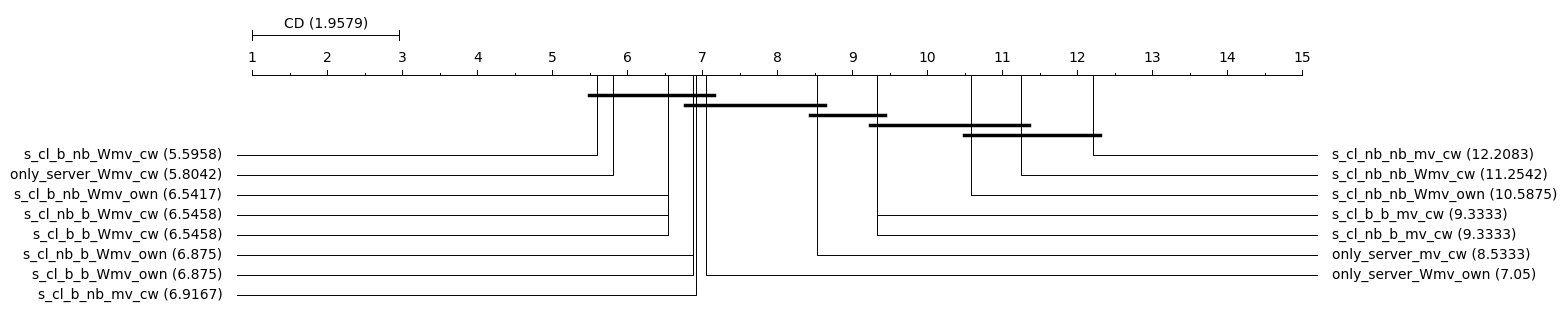

In [17]:

num_cases = fullacc_results.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


In [ ]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()



# F1-score results


In [13]:

f1_resultsW_cw.columns =f1_resultsW_cw.columns + '_Wmv_cw'
f1_resultsW_own.columns =f1_resultsW_own.columns + '_Wmv_own'
f1_results_cw.columns =f1_results_cw.columns + '_mv_cw'
fullf1_results = pd.concat([f1_resultsW_cw,f1_resultsW_own,f1_results_cw],axis=1).round(decimals=3).reset_index()
path = os.path.abspath('') + '\\exp3results\\iidf1'
fullacc_results.to_csv(path_or_buf=path)
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(fullf1_results, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 362.3989583333341, p-value 1.3186296499156924e-10
{'only_server_Wmv_cw': 5.804166666666666, 's_cl_nb_nb_Wmv_cw': 11.254166666666666, 's_cl_nb_b_Wmv_cw': 6.545833333333333, 's_cl_b_nb_Wmv_cw': 5.595833333333333, 's_cl_b_b_Wmv_cw': 6.545833333333333, 'only_server_Wmv_own': 7.05, 's_cl_nb_nb_Wmv_own': 10.5875, 's_cl_nb_b_Wmv_own': 6.875, 's_cl_b_nb_Wmv_own': 6.541666666666667, 's_cl_b_b_Wmv_own': 6.875, 'only_server_mv_cw': 8.533333333333333, 's_cl_nb_nb_mv_cw': 12.208333333333334, 's_cl_nb_b_mv_cw': 9.333333333333334, 's_cl_b_nb_mv_cw': 6.916666666666667, 's_cl_b_b_mv_cw': 9.333333333333334}


[5.804166666666666, 11.254166666666666, 6.545833333333333, 5.595833333333333, 6.545833333333333, 7.05, 10.5875, 6.875, 6.541666666666667, 6.875, 8.533333333333333, 12.208333333333334, 9.333333333333334, 6.916666666666667, 9.333333333333334]
1.9579277739317371


C:\Users\mario\AppData\Local\Temp\ipykernel_22028\3970231258.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


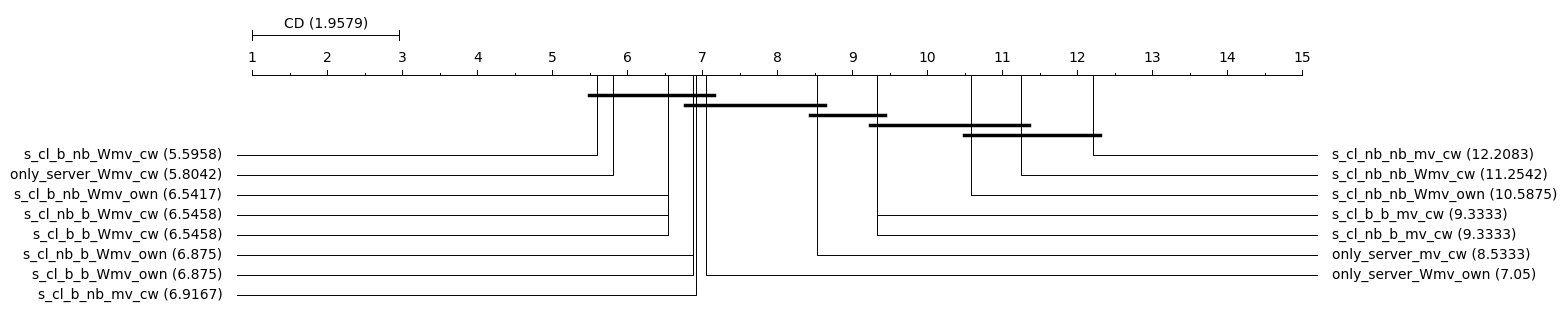

In [14]:

num_cases = fullacc_results.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                                    Comparison  Statistic (Z)       p-value  \
0      only_server_Wmv_cw vs s_cl_nb_nb_Wmv_cw       9.439677  0.000000e+00   
1       only_server_Wmv_cw vs s_cl_nb_b_Wmv_cw       1.284604  1.989306e-01   
2       only_server_Wmv_cw vs s_cl_b_nb_Wmv_cw       0.360844  7.182161e-01   
3        only_server_Wmv_cw vs s_cl_b_b_Wmv_cw       1.284604  1.989306e-01   
4    only_server_Wmv_cw vs only_server_Wmv_own       2.157847  3.093976e-02   
..                                         ...            ...           ...   
100        s_cl_nb_nb_mv_cw vs s_cl_b_nb_mv_cw       9.165436  0.000000e+00   
101         s_cl_nb_nb_mv_cw vs s_cl_b_b_mv_cw       4.979646  6.370066e-07   
102         s_cl_nb_b_mv_cw vs s_cl_b_nb_mv_cw       4.185789  2.841767e-05   
103          s_cl_nb_b_mv_cw vs s_cl_b_b_mv_cw       0.000000  1.000000e+00   
104          s_cl_b_nb_mv_cw vs s_cl_b_b_mv_cw       4.185789  2.841767e-05   

     Adjusted alpha  Adjusted p-value  alpha       

C:\Users\mario\AppData\Local\Temp\ipykernel_22028\2445730000.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


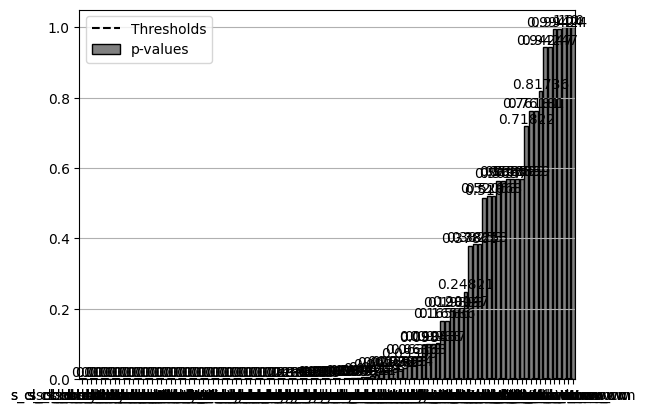

In [15]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()

# NIID quantity_skew

In [18]:
time0 = time.time()
iidresultsW_cw = experiment3search(data_distribution='niid_quantity_skew',distribution_param=0.5,datasets=datasets)
print("\n[INFO] Total Time (in minutes) =", (time.time() - time0) / 60)
for result in iidresultsW_cw:
    print(result)

c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\O


[INFO] Total Time (in minutes) = 28.843023999532065
FLGlobal_acc  only_server  only_server_std  s_cl_nb_nb  s_cl_nb_nb_std  \
bank            87.736423         0.824189   84.618475        1.191939   
adult           83.091728         0.957679   79.104696        2.909139   
nursery         95.192044         0.689597   87.886145        7.166792   
bcancer         91.626539         3.197634   87.227132        6.695320   

FLGlobal_acc  s_cl_nb_b  s_cl_nb_b_std  s_cl_b_nb  s_cl_b_nb_std   s_cl_b_b  \
bank          87.736423       0.824189  87.660727       0.949633  87.736423   
adult         82.438984       2.186807  83.131313       0.932224  82.438984   
nursery       88.898148       5.737764  95.203189       0.689479  88.898148   
bcancer       89.371455       5.482258  91.744596       3.227179  89.371455   

FLGlobal_acc  s_cl_b_b_std  
bank              0.824189  
adult             2.186807  
nursery           5.737764  
bcancer           5.482258  
FLlocal_acc  only_server  only_serv

In [19]:
time0 = time.time()
iidresultsW_own = experiment3search(data_distribution='niid_quantity_skew',distribution_param=0.5,datasets=datasets,server_alpha_weight_adj='own')
print("\n[INFO] Total Time (in minutes) =", (time.time() - time0) / 60)
for result in iidresultsW_own:
    print(result)
    


c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\O


[INFO] Total Time (in minutes) = 28.030941494305928
FLGlobal_acc  only_server  only_server_std  s_cl_nb_nb  s_cl_nb_nb_std  \
bank            87.736423         0.824189   84.618475        1.191939   
adult           82.939872         1.397026   79.107153        2.897975   
nursery         93.842593         4.542383   88.299726        6.674992   
bcancer         87.979571         7.097236   87.638942        6.597265   

FLGlobal_acc  s_cl_nb_b  s_cl_nb_b_std  s_cl_b_nb  s_cl_b_nb_std   s_cl_b_b  \
bank          87.723838       0.910990  87.683043       0.923795  87.723838   
adult         82.243789       2.492575  83.009760       1.360995  82.243789   
nursery       89.231139       5.374322  93.910322       4.483322  89.231139   
bcancer       88.566439       6.167097  88.946740       6.492930  88.566439   

FLGlobal_acc  s_cl_b_b_std  
bank              0.910990  
adult             2.492575  
nursery           5.374322  
bcancer           6.167097  
FLlocal_acc  only_server  only_serv

In [20]:
time0 = time.time()
iidresults_cw = experiment3search(data_distribution='niid_quantity_skew',distribution_param=0.5,datasets=datasets,public_data_prediction='majority_voting')
print("\n[INFO] Total Time (in minutes) =", (time.time() - time0) / 60)
for result in iidresults_cw:
    print(result)
    


c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\O


[INFO] Total Time (in minutes) = 18.3887353459994
FLGlobal_acc  only_server  only_server_std  s_cl_nb_nb  s_cl_nb_nb_std  \
bank            88.275628         0.084746   84.618475        1.191939   
adult           75.902948         0.103003   79.103399        2.910095   
nursery         33.401920         0.250785   86.669753        8.689788   
bcancer         36.893753         1.340466   86.754218        6.739196   

FLGlobal_acc  s_cl_nb_b  s_cl_nb_b_std  s_cl_b_nb  s_cl_b_nb_std   s_cl_b_b  \
bank          88.275628       0.084746  88.138099       0.639349  88.275628   
adult         79.121280       2.846812  76.485463       1.615389  79.121280   
nursery       86.671468       8.679365  57.802812      27.678402  86.671468   
bcancer       86.754218       6.739196  86.754218       6.739196  86.754218   

FLGlobal_acc  s_cl_b_b_std  
bank              0.084746  
adult             2.846812  
nursery           8.679365  
bcancer           6.739196  
FLlocal_acc  only_server  only_server

# Accuracy results


In [21]:

_,_,_,_,_,_,acc_resultsW_cw,f1_resultsW_cw = iidresultsW_cw
_,_,_,_,_,_,acc_resultsW_own,f1_resultsW_own = iidresultsW_own
_,_,_,_,_,_,acc_results_cw,f1_results_cw = iidresults_cw
acc_resultsW_cw.columns =acc_resultsW_cw.columns + '_Wmv_cw'
acc_resultsW_own.columns =acc_resultsW_own.columns + '_Wmv_own'
acc_results_cw.columns =acc_results_cw.columns + '_mv_cw'
fullacc_results = pd.concat([acc_resultsW_cw,acc_resultsW_own,acc_results_cw],axis=1).round(decimals=3).reset_index()
path = os.path.abspath('') + '\\exp3results\\niid_quantity_skewacc'
fullacc_results.to_csv(path_or_buf=path)
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(fullacc_results, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 726.8512500000006, p-value 2.2110224762172948e-10
{'only_server_Wmv_cw': 3.6791666666666667, 's_cl_nb_nb_Wmv_cw': 11.058333333333334, 's_cl_nb_b_Wmv_cw': 5.983333333333333, 's_cl_b_nb_Wmv_cw': 3.7625, 's_cl_b_b_Wmv_cw': 5.983333333333333, 'only_server_Wmv_own': 6.025, 's_cl_nb_nb_Wmv_own': 10.545833333333333, 's_cl_nb_b_Wmv_own': 6.816666666666666, 's_cl_b_nb_Wmv_own': 5.308333333333334, 's_cl_b_b_Wmv_own': 6.816666666666666, 'only_server_mv_cw': 12.2625, 's_cl_nb_nb_mv_cw': 11.958333333333334, 's_cl_nb_b_mv_cw': 9.425, 's_cl_b_nb_mv_cw': 10.95, 's_cl_b_b_mv_cw': 9.425}


[3.6791666666666667, 11.058333333333334, 5.983333333333333, 3.7625, 5.983333333333333, 6.025, 10.545833333333333, 6.816666666666666, 5.308333333333334, 6.816666666666666, 12.2625, 11.958333333333334, 9.425, 10.95, 9.425]
1.9579277739317371


C:\Users\mario\AppData\Local\Temp\ipykernel_22028\3970231258.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


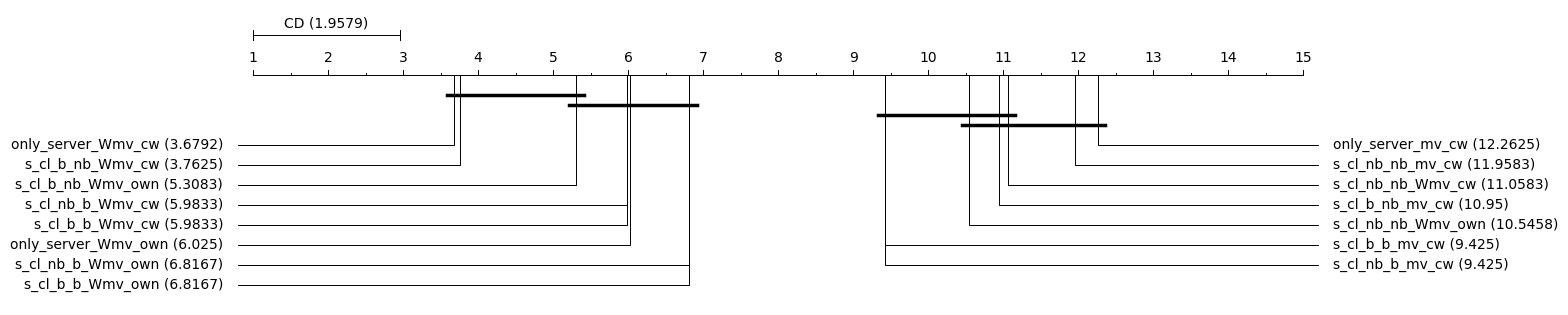

In [22]:

num_cases = fullacc_results.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                                    Comparison  Statistic (Z)   p-value  \
0      only_server_Wmv_cw vs s_cl_nb_nb_Wmv_cw      12.781092  0.000000   
1       only_server_Wmv_cw vs s_cl_nb_b_Wmv_cw       3.990934  0.000066   
2       only_server_Wmv_cw vs s_cl_b_nb_Wmv_cw       0.144338  0.885234   
3        only_server_Wmv_cw vs s_cl_b_b_Wmv_cw       3.990934  0.000066   
4    only_server_Wmv_cw vs only_server_Wmv_own       4.063103  0.000048   
..                                         ...            ...       ...   
100        s_cl_nb_nb_mv_cw vs s_cl_b_nb_mv_cw       1.746485  0.080727   
101         s_cl_nb_nb_mv_cw vs s_cl_b_b_mv_cw       4.387862  0.000011   
102         s_cl_nb_b_mv_cw vs s_cl_b_nb_mv_cw       2.641377  0.008257   
103          s_cl_nb_b_mv_cw vs s_cl_b_b_mv_cw       0.000000  1.000000   
104          s_cl_b_nb_mv_cw vs s_cl_b_b_mv_cw       2.641377  0.008257   

     Adjusted alpha  Adjusted p-value  alpha            Results  
0          0.000476          0.00

C:\Users\mario\AppData\Local\Temp\ipykernel_22028\844582222.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


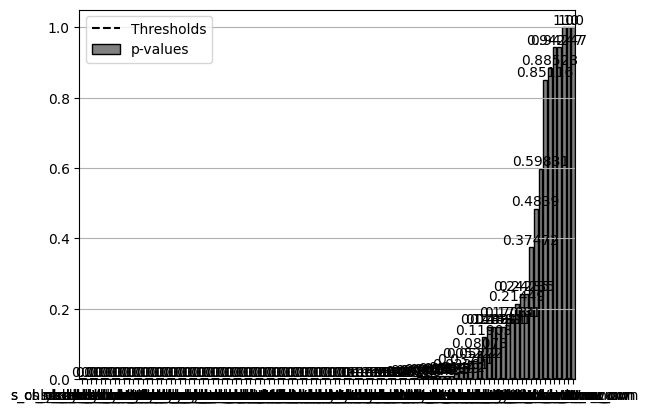

In [23]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()



# F1-score results


In [24]:

f1_resultsW_cw.columns =f1_resultsW_cw.columns + '_Wmv_cw'
f1_resultsW_own.columns =f1_resultsW_own.columns + '_Wmv_own'
f1_results_cw.columns =f1_results_cw.columns + '_mv_cw'
fullf1_results = pd.concat([f1_resultsW_cw,f1_resultsW_own,f1_results_cw],axis=1).round(decimals=3).reset_index()
path = os.path.abspath('') + '\\exp3results\\niid_quantity_skewf1'
fullacc_results.to_csv(path_or_buf=path)
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(fullf1_results, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 456.18208333333405, p-value 2.1412849271484902e-10
{'only_server_Wmv_cw': 5.141666666666667, 's_cl_nb_nb_Wmv_cw': 11.5375, 's_cl_nb_b_Wmv_cw': 6.195833333333334, 's_cl_b_nb_Wmv_cw': 4.983333333333333, 's_cl_b_b_Wmv_cw': 6.195833333333334, 'only_server_Wmv_own': 7.3125, 's_cl_nb_nb_Wmv_own': 11.025, 's_cl_nb_b_Wmv_own': 7.004166666666666, 's_cl_b_nb_Wmv_own': 6.304166666666666, 's_cl_b_b_Wmv_own': 7.004166666666666, 'only_server_mv_cw': 8.3375, 's_cl_nb_nb_mv_cw': 12.545833333333333, 's_cl_nb_b_mv_cw': 9.454166666666667, 's_cl_b_nb_mv_cw': 7.504166666666666, 's_cl_b_b_mv_cw': 9.454166666666667}


[5.141666666666667, 11.5375, 6.195833333333334, 4.983333333333333, 6.195833333333334, 7.3125, 11.025, 7.004166666666666, 6.304166666666666, 7.004166666666666, 8.3375, 12.545833333333333, 9.454166666666667, 7.504166666666666, 9.454166666666667]
1.9579277739317371


C:\Users\mario\AppData\Local\Temp\ipykernel_22028\3970231258.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


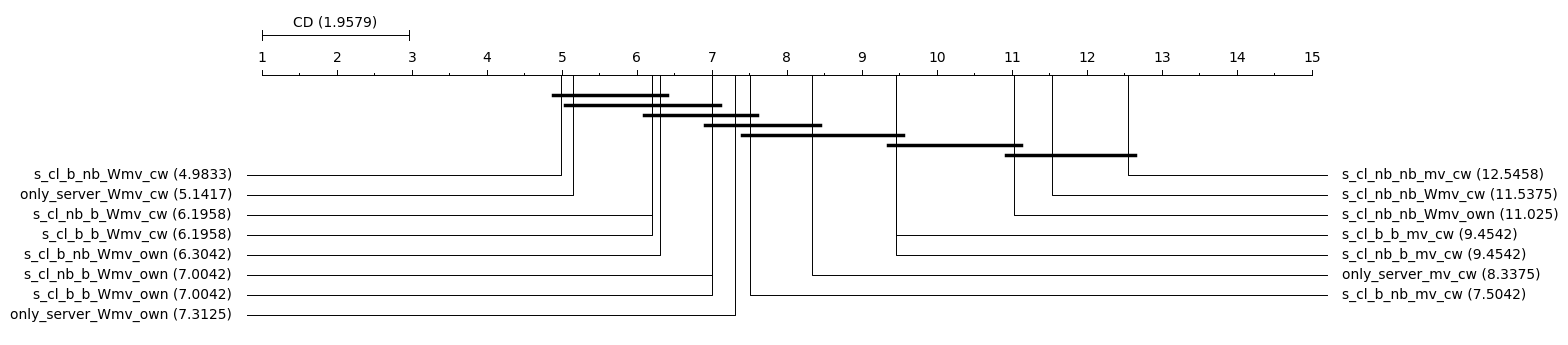

In [25]:

num_cases = fullacc_results.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                                    Comparison  Statistic (Z)       p-value  \
0      only_server_Wmv_cw vs s_cl_nb_nb_Wmv_cw      11.077908  0.000000e+00   
1       only_server_Wmv_cw vs s_cl_nb_b_Wmv_cw       1.825870  6.786981e-02   
2       only_server_Wmv_cw vs s_cl_b_nb_Wmv_cw       0.274241  7.838991e-01   
3        only_server_Wmv_cw vs s_cl_b_b_Wmv_cw       1.825870  6.786981e-02   
4    only_server_Wmv_cw vs only_server_Wmv_own       3.759994  1.699177e-04   
..                                         ...            ...           ...   
100        s_cl_nb_nb_mv_cw vs s_cl_b_nb_mv_cw       8.732423  0.000000e+00   
101         s_cl_nb_nb_mv_cw vs s_cl_b_b_mv_cw       5.354924  8.559251e-08   
102         s_cl_nb_b_mv_cw vs s_cl_b_nb_mv_cw       3.377499  7.314820e-04   
103          s_cl_nb_b_mv_cw vs s_cl_b_b_mv_cw       0.000000  1.000000e+00   
104          s_cl_b_nb_mv_cw vs s_cl_b_b_mv_cw       3.377499  7.314820e-04   

     Adjusted alpha  Adjusted p-value  alpha       

C:\Users\mario\AppData\Local\Temp\ipykernel_22028\2445730000.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


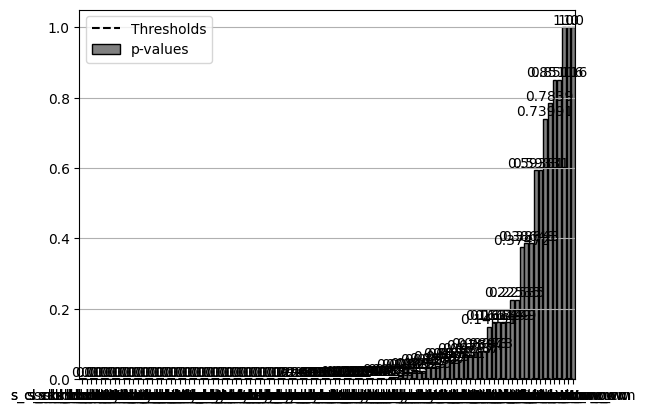

In [26]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()

# NIID dirichlet label skew

In [27]:
time0 = time.time()
iidresultsW_cw = experiment3search(data_distribution='niid_dirichlet_label_skew',distribution_param=0.5,datasets=datasets)
print("\n[INFO] Total Time (in minutes) =", (time.time() - time0) / 60)
for result in iidresultsW_cw:
    print(result)
    


c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\O


[INFO] Total Time (in minutes) = 24.335693955421448
FLGlobal_acc  only_server  only_server_std  s_cl_nb_nb  s_cl_nb_nb_std  \
bank            88.207307         0.392296   76.775291       21.502781   
adult           81.872782         2.644028   71.460756       16.998739   
nursery         93.189300         1.223435   68.038923       21.185701   
bcancer         90.420429         3.183204   71.367715       19.752583   

FLGlobal_acc  s_cl_nb_b  s_cl_nb_b_std  s_cl_b_nb  s_cl_b_nb_std   s_cl_b_b  \
bank          84.505872      14.138683  88.177618       0.495864  84.505872   
adult         78.785558      10.733237  81.884589       2.504973  78.785558   
nursery       86.784294       8.829443  92.429355       4.474399  86.784294   
bcancer       80.348472      16.971301  84.106521      13.293061  80.348472   

FLGlobal_acc  s_cl_b_b_std  
bank             14.138683  
adult            10.733237  
nursery           8.829443  
bcancer          16.971301  
FLlocal_acc  only_server  only_serv

In [28]:
time0 = time.time()
iidresultsW_own = experiment3search(data_distribution='niid_dirichlet_label_skew',distribution_param=0.5,datasets=datasets,server_alpha_weight_adj='own')
print("\n[INFO] Total Time (in minutes) =", (time.time() - time0) / 60)
for result in iidresultsW_own:
    print(result)
    


c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\O


[INFO] Total Time (in minutes) = 461.2630257447561
FLGlobal_acc  only_server  only_server_std  s_cl_nb_nb  s_cl_nb_nb_std  \
bank            88.220627         0.351305   76.726924       21.733885   
adult           81.471267         2.931893   70.861316       17.982918   
nursery         92.705247         2.937001   67.865741       21.392470   
bcancer         83.032741        10.824641   70.831509       19.465727   

FLGlobal_acc  s_cl_nb_b  s_cl_nb_b_std  s_cl_b_nb  s_cl_b_nb_std   s_cl_b_b  \
bank          77.972307      22.257125  78.811538      22.452125  77.972307   
adult         73.149877      16.548808  75.012422      17.299502  73.149877   
nursery       83.566872      14.558364  91.625171       6.633054  83.566872   
bcancer       76.481760      16.849671  77.034747      17.073078  76.481760   

FLGlobal_acc  s_cl_b_b_std  
bank             22.257125  
adult            16.548808  
nursery          14.558364  
bcancer          16.849671  
FLlocal_acc  only_server  only_serve

In [29]:
time0 = time.time()
iidresults_cw = experiment3search(data_distribution='niid_dirichlet_label_skew',distribution_param=0.5,datasets=datasets,public_data_prediction='majority_voting')
print("\n[INFO] Total Time (in minutes) =", (time.time() - time0) / 60)
for result in iidresults_cw:
    print(result)
    


c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\O


[INFO] Total Time (in minutes) = 18.894144634405773
FLGlobal_acc  only_server  only_server_std  s_cl_nb_nb  s_cl_nb_nb_std  \
bank            88.281035         0.084618   76.775929       21.501716   
adult           75.906361         0.103354   71.496314       17.061359   
nursery         33.413923         0.257523   73.272462       18.053203   
bcancer         36.893753         1.340466   74.669539       16.244785   

FLGlobal_acc  s_cl_nb_b  s_cl_nb_b_std  s_cl_b_nb  s_cl_b_nb_std   s_cl_b_b  \
bank          84.567805      14.150777  88.237388       0.335947  84.567805   
adult         74.638957       9.944414  76.048867       2.072701  74.638957   
nursery       73.473937      17.923464  56.358539      22.198065  73.473937   
bcancer       74.669539      16.244785  74.669539      16.244785  74.669539   

FLGlobal_acc  s_cl_b_b_std  
bank             14.150777  
adult             9.944414  
nursery          17.923464  
bcancer          16.244785  
FLlocal_acc  only_server  only_serv

# Accuracy results


In [30]:

_,_,_,_,_,_,acc_resultsW_cw,f1_resultsW_cw = iidresultsW_cw
_,_,_,_,_,_,acc_resultsW_own,f1_resultsW_own = iidresultsW_own
_,_,_,_,_,_,acc_results_cw,f1_results_cw = iidresults_cw
acc_resultsW_cw.columns =acc_resultsW_cw.columns + '_Wmv_cw'
acc_resultsW_own.columns =acc_resultsW_own.columns + '_Wmv_own'
acc_results_cw.columns =acc_results_cw.columns + '_mv_cw'
fullacc_results = pd.concat([acc_resultsW_cw,acc_resultsW_own,acc_results_cw],axis=1).round(decimals=3).reset_index()
path = os.path.abspath('') + '\\exp3results\\niid_dirichlet_label_skewacc'
fullacc_results.to_csv(path_or_buf=path)
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(fullacc_results, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 1051.821041666667, p-value 0.0
{'only_server_Wmv_cw': 2.029166666666667, 's_cl_nb_nb_Wmv_cw': 12.825, 's_cl_nb_b_Wmv_cw': 5.4625, 's_cl_b_nb_Wmv_cw': 2.925, 's_cl_b_b_Wmv_cw': 5.4625, 'only_server_Wmv_own': 3.175, 's_cl_nb_nb_Wmv_own': 13.558333333333334, 's_cl_nb_b_Wmv_own': 9.125, 's_cl_b_nb_Wmv_own': 7.579166666666667, 's_cl_b_b_Wmv_own': 9.125, 'only_server_mv_cw': 10.358333333333333, 's_cl_nb_nb_mv_cw': 11.55, 's_cl_nb_b_mv_cw': 9.0125, 's_cl_b_nb_mv_cw': 8.8, 's_cl_b_b_mv_cw': 9.0125}


[2.029166666666667, 12.825, 5.4625, 2.925, 5.4625, 3.175, 13.558333333333334, 9.125, 7.579166666666667, 9.125, 10.358333333333333, 11.55, 9.0125, 8.8, 9.0125]
1.9579277739317371


C:\Users\mario\AppData\Local\Temp\ipykernel_22028\3970231258.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


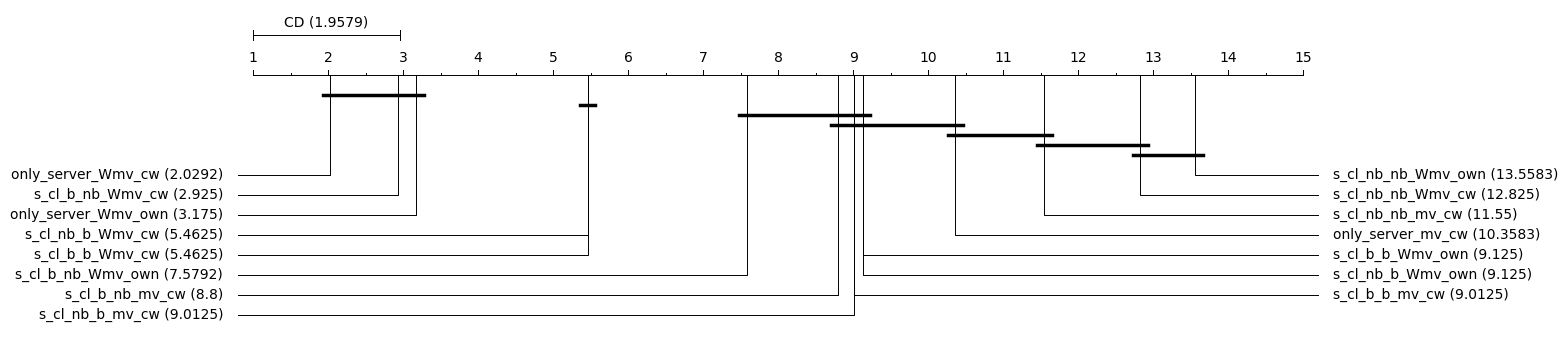

In [31]:

num_cases = fullacc_results.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                                    Comparison  Statistic (Z)       p-value  \
0      only_server_Wmv_cw vs s_cl_nb_nb_Wmv_cw      18.698932  0.000000e+00   
1       only_server_Wmv_cw vs s_cl_nb_b_Wmv_cw       5.946708  2.735892e-09   
2       only_server_Wmv_cw vs s_cl_b_nb_Wmv_cw       1.551629  1.207511e-01   
3        only_server_Wmv_cw vs s_cl_b_b_Wmv_cw       5.946708  2.735892e-09   
4    only_server_Wmv_cw vs only_server_Wmv_own       1.984642  4.718437e-02   
..                                         ...            ...           ...   
100        s_cl_nb_nb_mv_cw vs s_cl_b_nb_mv_cw       4.763140  1.906038e-06   
101         s_cl_nb_nb_mv_cw vs s_cl_b_b_mv_cw       4.395079  1.107325e-05   
102         s_cl_nb_b_mv_cw vs s_cl_b_nb_mv_cw       0.368061  7.128279e-01   
103          s_cl_nb_b_mv_cw vs s_cl_b_b_mv_cw       0.000000  1.000000e+00   
104          s_cl_b_nb_mv_cw vs s_cl_b_b_mv_cw       0.368061  7.128279e-01   

     Adjusted alpha  Adjusted p-value  alpha       

C:\Users\mario\AppData\Local\Temp\ipykernel_22028\844582222.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


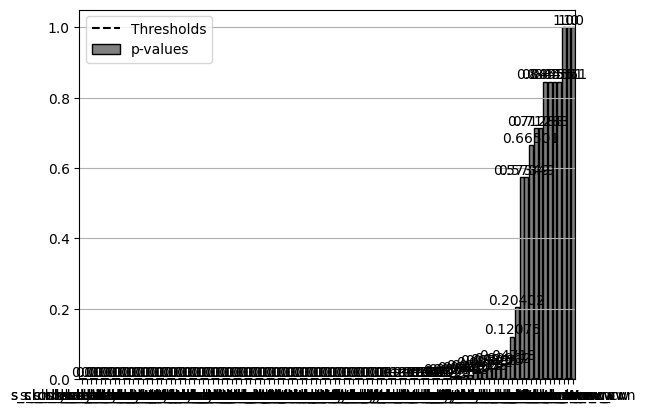

In [32]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()



# F1-score results


In [33]:

f1_resultsW_cw.columns =f1_resultsW_cw.columns + '_Wmv_cw'
f1_resultsW_own.columns =f1_resultsW_own.columns + '_Wmv_own'
f1_results_cw.columns =f1_results_cw.columns + '_mv_cw'
fullf1_results = pd.concat([f1_resultsW_cw,f1_resultsW_own,f1_results_cw],axis=1).round(decimals=3).reset_index()
path = os.path.abspath('') + '\\exp3results\\niid_dirichlet_label_skewf1'
fullacc_results.to_csv(path_or_buf=path)
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(fullf1_results, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 847.7900000000009, p-value 2.9268176771068966e-10
{'only_server_Wmv_cw': 3.1041666666666665, 's_cl_nb_nb_Wmv_cw': 13.0875, 's_cl_nb_b_Wmv_cw': 6.5, 's_cl_b_nb_Wmv_cw': 3.8666666666666667, 's_cl_b_b_Wmv_cw': 6.5, 'only_server_Wmv_own': 3.4458333333333333, 's_cl_nb_nb_Wmv_own': 13.216666666666667, 's_cl_nb_b_Wmv_own': 9.233333333333333, 's_cl_b_nb_Wmv_own': 7.675, 's_cl_b_b_Wmv_own': 9.233333333333333, 'only_server_mv_cw': 8.216666666666667, 's_cl_nb_nb_mv_cw': 12.2375, 's_cl_nb_b_mv_cw': 8.241666666666667, 's_cl_b_nb_mv_cw': 7.2, 's_cl_b_b_mv_cw': 8.241666666666667}


[3.1041666666666665, 13.0875, 6.5, 3.8666666666666667, 6.5, 3.4458333333333333, 13.216666666666667, 9.233333333333333, 7.675, 9.233333333333333, 8.216666666666667, 12.2375, 8.241666666666667, 7.2, 8.241666666666667]
1.9579277739317371


C:\Users\mario\AppData\Local\Temp\ipykernel_22028\3970231258.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


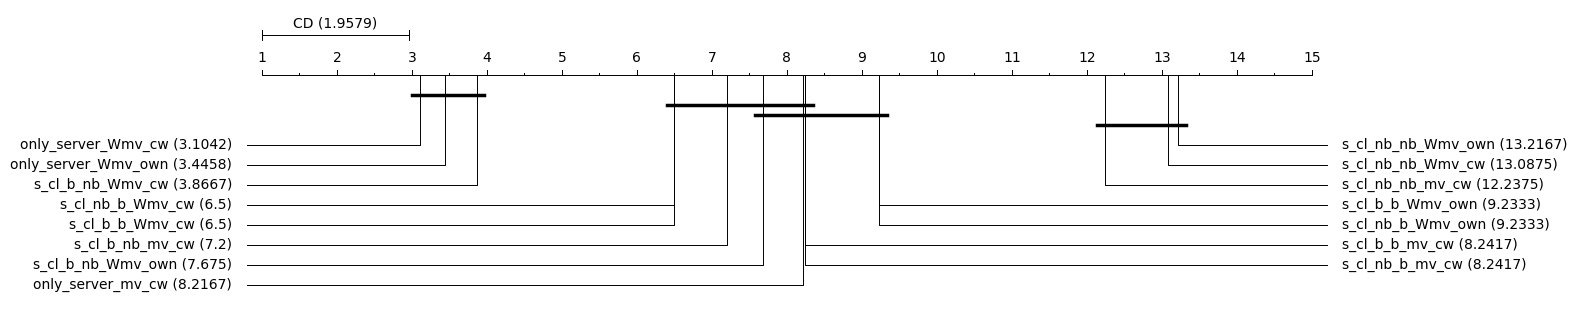

In [34]:

num_cases = fullacc_results.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                                    Comparison  Statistic (Z)       p-value  \
0      only_server_Wmv_cw vs s_cl_nb_nb_Wmv_cw      17.291641  0.000000e+00   
1       only_server_Wmv_cw vs s_cl_nb_b_Wmv_cw       5.881756  4.059368e-09   
2       only_server_Wmv_cw vs s_cl_b_nb_Wmv_cw       1.320689  1.866052e-01   
3        only_server_Wmv_cw vs s_cl_b_b_Wmv_cw       5.881756  4.059368e-09   
4    only_server_Wmv_cw vs only_server_Wmv_own       0.591784  5.539952e-01   
..                                         ...            ...           ...   
100        s_cl_nb_nb_mv_cw vs s_cl_b_nb_mv_cw       8.725206  0.000000e+00   
101         s_cl_nb_nb_mv_cw vs s_cl_b_b_mv_cw       6.920986  4.485079e-12   
102         s_cl_nb_b_mv_cw vs s_cl_b_nb_mv_cw       1.804220  7.119689e-02   
103          s_cl_nb_b_mv_cw vs s_cl_b_b_mv_cw       0.000000  1.000000e+00   
104          s_cl_b_nb_mv_cw vs s_cl_b_b_mv_cw       1.804220  7.119689e-02   

     Adjusted alpha  Adjusted p-value  alpha       

C:\Users\mario\AppData\Local\Temp\ipykernel_22028\2445730000.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


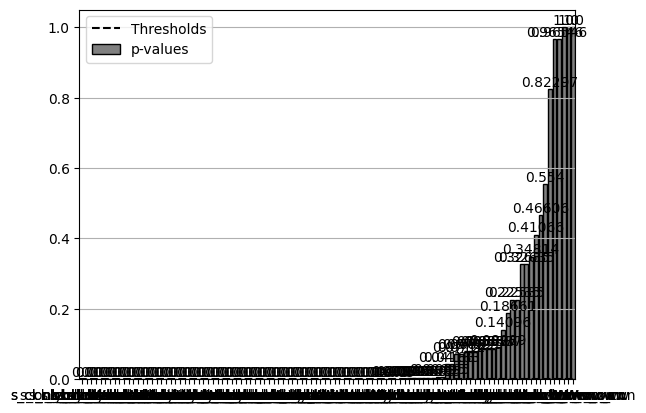

In [35]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()

# NIID quantity label skew

In [36]:
datasets = {'nursery':(X_data_nursery,targets_nursery)}

In [37]:
time0 = time.time()
iidresultsW_cw = experiment3search(data_distribution='niid_label_quantity_skew',distribution_param=3,datasets=datasets)
print("\n[INFO] Total Time (in minutes) =", (time.time() - time0) / 60)
for result in iidresultsW_cw:
    print(result)
    


c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\O


[INFO] Total Time (in minutes) = 3.939711034297943
FLGlobal_acc  only_server  only_server_std  s_cl_nb_nb  s_cl_nb_nb_std  \
nursery         92.842936          1.38213   56.454561       19.353591   

FLGlobal_acc  s_cl_nb_b  s_cl_nb_b_std  s_cl_b_nb  s_cl_b_nb_std  s_cl_b_b  \
nursery        72.60631      18.384032  91.843107       5.874303  72.60631   

FLGlobal_acc  s_cl_b_b_std  
nursery          18.384032  
FLlocal_acc  only_server  only_server_std  s_cl_nb_nb  s_cl_nb_nb_std  \
nursery        90.859755         9.623348    95.25444        4.822725   

FLlocal_acc  s_cl_nb_b  s_cl_nb_b_std  s_cl_b_nb  s_cl_b_nb_std   s_cl_b_b  \
nursery      93.518197       6.292984  91.152586       9.490666  93.518197   

FLlocal_acc  s_cl_b_b_std  
nursery          6.292984  
centralized_acc       mean       std
nursery          99.223251  0.267737
FLGlobal_f1  only_server  only_server_std  s_cl_nb_nb  s_cl_nb_nb_std  \
nursery        93.263385         1.129174   66.907812       17.396451   

FLG

In [38]:
time0 = time.time()
iidresultsW_own = experiment3search(data_distribution='niid_label_quantity_skew',distribution_param=3,datasets=datasets,server_alpha_weight_adj='own')
print("\n[INFO] Total Time (in minutes) =", (time.time() - time0) / 60)
for result in iidresultsW_own:
    print(result)
    


c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\O


[INFO] Total Time (in minutes) = 3.9919198314348856
FLGlobal_acc  only_server  only_server_std  s_cl_nb_nb  s_cl_nb_nb_std  \
nursery         92.367627         2.103476   56.533265       19.438995   

FLGlobal_acc  s_cl_nb_b  s_cl_nb_b_std  s_cl_b_nb  s_cl_b_nb_std   s_cl_b_b  \
nursery       72.234396      18.101945  89.879115       9.748064  72.234396   

FLGlobal_acc  s_cl_b_b_std  
nursery          18.101945  
FLlocal_acc  only_server  only_server_std  s_cl_nb_nb  s_cl_nb_nb_std  \
nursery        90.551615         9.637876   95.167825        4.856219   

FLlocal_acc  s_cl_nb_b  s_cl_nb_b_std  s_cl_b_nb  s_cl_b_nb_std   s_cl_b_b  \
nursery      93.609174       6.029359  91.411436       9.444904  93.609174   

FLlocal_acc  s_cl_b_b_std  
nursery          6.029359  
centralized_acc       mean       std
nursery          99.223251  0.267737
FLGlobal_f1  only_server  only_server_std  s_cl_nb_nb  s_cl_nb_nb_std  \
nursery        92.799809         1.943867   66.905166       17.413156   



In [39]:
time0 = time.time()
iidresults_cw = experiment3search(data_distribution='niid_label_quantity_skew',distribution_param=3,datasets=datasets,public_data_prediction='majority_voting')
print("\n[INFO] Total Time (in minutes) =", (time.time() - time0) / 60)
for result in iidresults_cw:
    print(result)
    


c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\O


[INFO] Total Time (in minutes) = 2.279334831237793
FLGlobal_acc  only_server  only_server_std  s_cl_nb_nb  s_cl_nb_nb_std  \
nursery         33.415638         0.261247   56.535494       19.347578   

FLGlobal_acc  s_cl_nb_b  s_cl_nb_b_std  s_cl_b_nb  s_cl_b_nb_std   s_cl_b_b  \
nursery       56.321845      19.587641  52.915638      17.460588  56.321845   

FLGlobal_acc  s_cl_b_b_std  
nursery          19.587641  
FLlocal_acc  only_server  only_server_std  s_cl_nb_nb  s_cl_nb_nb_std  \
nursery        31.261431        30.757341   95.459388        4.794873   

FLlocal_acc  s_cl_nb_b  s_cl_nb_b_std  s_cl_b_nb  s_cl_b_nb_std  s_cl_b_b  \
nursery       94.76995        4.66646  86.786068      13.960515  94.76995   

FLlocal_acc  s_cl_b_b_std  
nursery           4.66646  
centralized_acc       mean       std
nursery          99.223251  0.267737
FLGlobal_f1  only_server  only_server_std  s_cl_nb_nb  s_cl_nb_nb_std  \
nursery        49.770254         0.253971   66.907712       17.406045   

FLG

# Accuracy results


In [40]:

_,_,_,_,_,_,acc_resultsW_cw,f1_resultsW_cw = iidresultsW_cw
_,_,_,_,_,_,acc_resultsW_own,f1_resultsW_own = iidresultsW_own
_,_,_,_,_,_,acc_results_cw,f1_results_cw = iidresults_cw
acc_resultsW_cw.columns =acc_resultsW_cw.columns + '_Wmv_cw'
acc_resultsW_own.columns =acc_resultsW_own.columns + '_Wmv_own'
acc_results_cw.columns =acc_results_cw.columns + '_mv_cw'
fullacc_results = pd.concat([acc_resultsW_cw,acc_resultsW_own,acc_results_cw],axis=1).round(decimals=3).reset_index()
path = os.path.abspath('') + '\\exp3results\\niid_label_quantity_skewacc'
fullacc_results.to_csv(path_or_buf=path)
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(fullacc_results, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 395.6416666666669, p-value 1.5777057438270958e-10
{'only_server_Wmv_cw': 1.5666666666666667, 's_cl_nb_nb_Wmv_cw': 10.366666666666667, 's_cl_nb_b_Wmv_cw': 6.316666666666666, 's_cl_b_nb_Wmv_cw': 2.2666666666666666, 's_cl_b_b_Wmv_cw': 6.316666666666666, 'only_server_Wmv_own': 2.466666666666667, 's_cl_nb_nb_Wmv_own': 10.6, 's_cl_nb_b_Wmv_own': 6.816666666666666, 's_cl_b_nb_Wmv_own': 3.7, 's_cl_b_b_Wmv_own': 6.816666666666666, 'only_server_mv_cw': 15.0, 's_cl_nb_nb_mv_cw': 9.833333333333334, 's_cl_nb_b_mv_cw': 12.0, 's_cl_b_nb_mv_cw': 13.933333333333334, 's_cl_b_b_mv_cw': 12.0}


[1.5666666666666667, 10.366666666666667, 6.316666666666666, 2.2666666666666666, 6.316666666666666, 2.466666666666667, 10.6, 6.816666666666666, 3.7, 6.816666666666666, 15.0, 9.833333333333334, 12.0, 13.933333333333334, 12.0]
3.9158555478634742


C:\Users\mario\AppData\Local\Temp\ipykernel_22028\3970231258.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


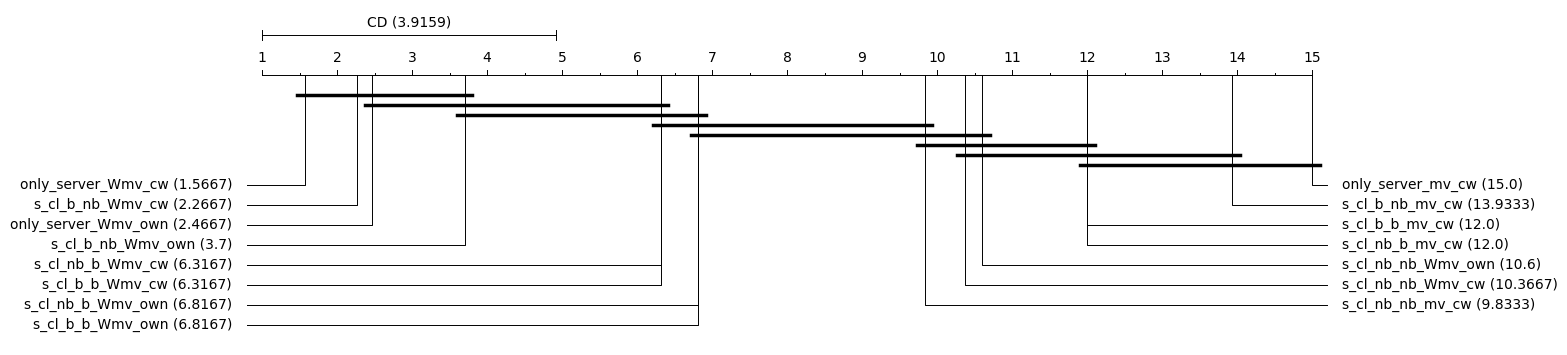

In [41]:

num_cases = fullacc_results.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                                    Comparison  Statistic (Z)       p-value  \
0      only_server_Wmv_cw vs s_cl_nb_nb_Wmv_cw       7.621024  2.531308e-14   
1       only_server_Wmv_cw vs s_cl_nb_b_Wmv_cw       4.113621  3.895013e-05   
2       only_server_Wmv_cw vs s_cl_b_nb_Wmv_cw       0.606218  5.443701e-01   
3        only_server_Wmv_cw vs s_cl_b_b_Wmv_cw       4.113621  3.895013e-05   
4    only_server_Wmv_cw vs only_server_Wmv_own       0.779423  4.357307e-01   
..                                         ...            ...           ...   
100        s_cl_nb_nb_mv_cw vs s_cl_b_nb_mv_cw       3.550704  3.842020e-04   
101         s_cl_nb_nb_mv_cw vs s_cl_b_b_mv_cw       1.876388  6.060197e-02   
102         s_cl_nb_b_mv_cw vs s_cl_b_nb_mv_cw       1.674316  9.406855e-02   
103          s_cl_nb_b_mv_cw vs s_cl_b_b_mv_cw       0.000000  1.000000e+00   
104          s_cl_b_nb_mv_cw vs s_cl_b_b_mv_cw       1.674316  9.406855e-02   

     Adjusted alpha  Adjusted p-value  alpha       

C:\Users\mario\AppData\Local\Temp\ipykernel_22028\844582222.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


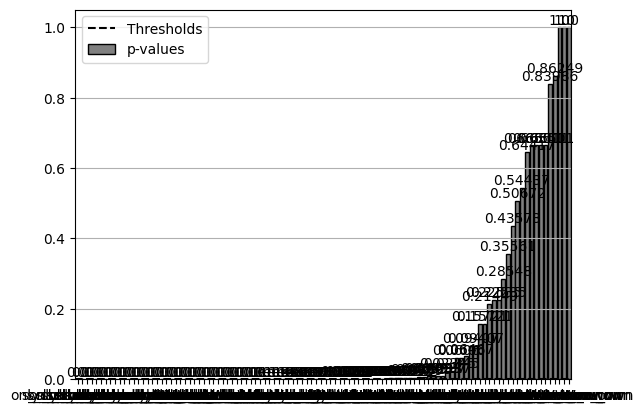

In [42]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()



# F1-score results


In [43]:

f1_resultsW_cw.columns =f1_resultsW_cw.columns + '_Wmv_cw'
f1_resultsW_own.columns =f1_resultsW_own.columns + '_Wmv_own'
f1_results_cw.columns =f1_results_cw.columns + '_mv_cw'
fullf1_results = pd.concat([f1_resultsW_cw,f1_resultsW_own,f1_results_cw],axis=1).round(decimals=3).reset_index()
path = os.path.abspath('') + '\\exp3results\\niid_label_quantity_skewf1'
fullacc_results.to_csv(path_or_buf=path)
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(fullf1_results, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 388.7800000000002, p-value 1.453113185334587e-10
{'only_server_Wmv_cw': 1.5666666666666667, 's_cl_nb_nb_Wmv_cw': 11.066666666666666, 's_cl_nb_b_Wmv_cw': 6.166666666666667, 's_cl_b_nb_Wmv_cw': 2.2666666666666666, 's_cl_b_b_Wmv_cw': 6.166666666666667, 'only_server_Wmv_own': 2.466666666666667, 's_cl_nb_nb_Wmv_own': 11.65, 's_cl_nb_b_Wmv_own': 7.066666666666666, 's_cl_b_nb_Wmv_own': 3.7, 's_cl_b_b_Wmv_own': 7.066666666666666, 'only_server_mv_cw': 15.0, 's_cl_nb_nb_mv_cw': 12.016666666666667, 's_cl_nb_b_mv_cw': 10.15, 's_cl_b_nb_mv_cw': 13.5, 's_cl_b_b_mv_cw': 10.15}


[1.5666666666666667, 11.066666666666666, 6.166666666666667, 2.2666666666666666, 6.166666666666667, 2.466666666666667, 11.65, 7.066666666666666, 3.7, 7.066666666666666, 15.0, 12.016666666666667, 10.15, 13.5, 10.15]
3.9158555478634742


C:\Users\mario\AppData\Local\Temp\ipykernel_22028\3970231258.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


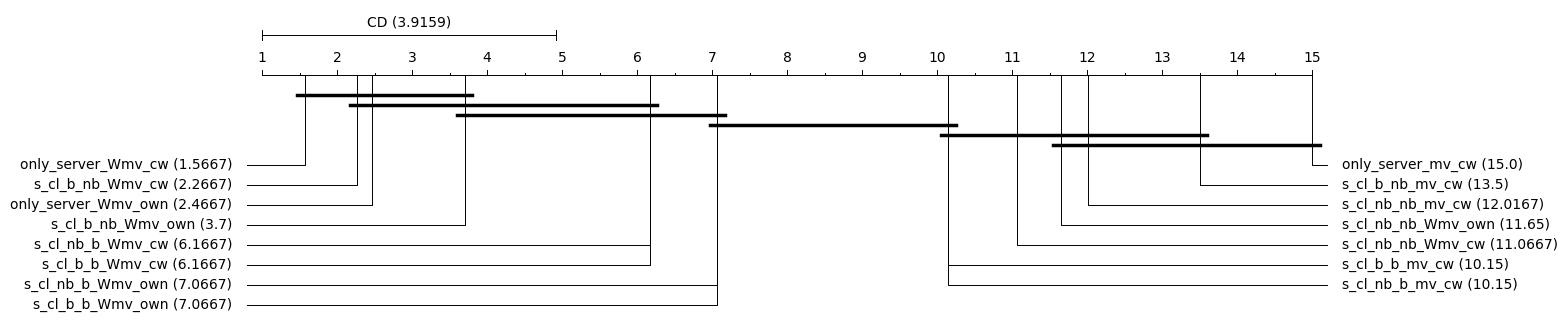

In [44]:

num_cases = fullacc_results.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                                    Comparison  Statistic (Z)       p-value  \
0      only_server_Wmv_cw vs s_cl_nb_nb_Wmv_cw       8.227241  2.220446e-16   
1       only_server_Wmv_cw vs s_cl_nb_b_Wmv_cw       3.983717  6.784570e-05   
2       only_server_Wmv_cw vs s_cl_b_nb_Wmv_cw       0.606218  5.443701e-01   
3        only_server_Wmv_cw vs s_cl_b_b_Wmv_cw       3.983717  6.784570e-05   
4    only_server_Wmv_cw vs only_server_Wmv_own       0.779423  4.357307e-01   
..                                         ...            ...           ...   
100        s_cl_nb_nb_mv_cw vs s_cl_b_nb_mv_cw       1.284604  1.989306e-01   
101         s_cl_nb_nb_mv_cw vs s_cl_b_b_mv_cw       1.616581  1.059688e-01   
102         s_cl_nb_b_mv_cw vs s_cl_b_nb_mv_cw       2.901185  3.717542e-03   
103          s_cl_nb_b_mv_cw vs s_cl_b_b_mv_cw       0.000000  1.000000e+00   
104          s_cl_b_nb_mv_cw vs s_cl_b_b_mv_cw       2.901185  3.717542e-03   

     Adjusted alpha  Adjusted p-value  alpha       

C:\Users\mario\AppData\Local\Temp\ipykernel_22028\2445730000.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


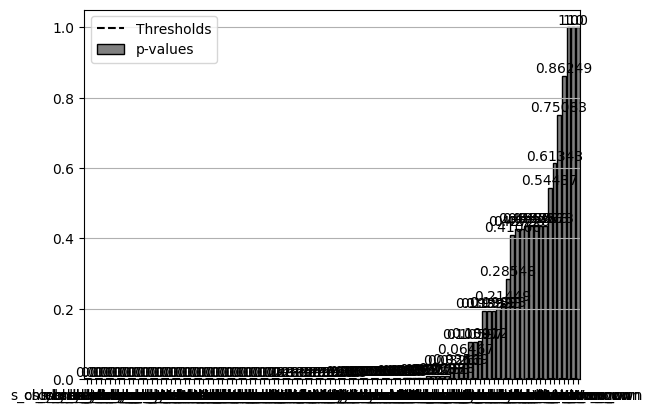

In [45]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()